# 로지스틱 회귀

## 데이터 준비

In [ ]:
import pandas as pd

In [ ]:
fish = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/fish_data.csv')

In [ ]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
import numpy as np

In [ ]:
np.unique(fish['Species'], return_counts=True)

(array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
       dtype=object),
 array([35, 11, 56, 17, 20, 14,  6]))

In [ ]:
fish.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [ ]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()
print(fish_input)

[[2.42000e+02 2.54000e+01 3.00000e+01 1.15200e+01 4.02000e+00]
 [2.90000e+02 2.63000e+01 3.12000e+01 1.24800e+01 4.30560e+00]
 [3.40000e+02 2.65000e+01 3.11000e+01 1.23778e+01 4.69610e+00]
 [3.63000e+02 2.90000e+01 3.35000e+01 1.27300e+01 4.45550e+00]
 [4.30000e+02 2.90000e+01 3.40000e+01 1.24440e+01 5.13400e+00]
 [4.50000e+02 2.97000e+01 3.47000e+01 1.36024e+01 4.92740e+00]
 [5.00000e+02 2.97000e+01 3.45000e+01 1.41795e+01 5.27850e+00]
 [3.90000e+02 3.00000e+01 3.50000e+01 1.26700e+01 4.69000e+00]
 [4.50000e+02 3.00000e+01 3.51000e+01 1.40049e+01 4.84380e+00]
 [5.00000e+02 3.07000e+01 3.62000e+01 1.42266e+01 4.95940e+00]
 [4.75000e+02 3.10000e+01 3.62000e+01 1.42628e+01 5.10420e+00]
 [5.00000e+02 3.10000e+01 3.62000e+01 1.43714e+01 4.81460e+00]
 [5.00000e+02 3.15000e+01 3.64000e+01 1.37592e+01 4.36800e+00]
 [3.40000e+02 3.20000e+01 3.73000e+01 1.39129e+01 5.07280e+00]
 [6.00000e+02 3.20000e+01 3.72000e+01 1.49544e+01 5.17080e+00]
 [6.00000e+02 3.20000e+01 3.72000e+01 1.54380e+01 5.580

In [ ]:
print(fish_input.shape, fish_target.shape)

(159, 5) (159,)


In [ ]:
print(fish_input[:10])


[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]
 [450.      29.7     34.7     13.6024   4.9274]
 [500.      29.7     34.5     14.1795   5.2785]
 [390.      30.      35.      12.67     4.69  ]
 [450.      30.      35.1     14.0049   4.8438]
 [500.      30.7     36.2     14.2266   4.9594]]


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss = StandardScaler()
ss.fit(fish_input)
fish_scaled = ss.transform(fish_input)

In [ ]:
print(fish_scaled)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_input, test_input, train_target, test_target = \
  train_test_split(fish_scaled, fish_target, random_state=42)

In [ ]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(119, 5) (119,)
(40, 5) (40,)


## 로지스틱 회귀


## $$ z = a \times weight + b \times length + c \times diagonal + d \times height + e \times width + f $$
## $$z= ax_0 + bx_1 + cx_2 + dx_3 + ex_4 + f $$

## $$z= w_0x_0 + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 +  b $$


## Sigmoid
## $$ \theta = \frac {1}{ 1+e^{-z}} $$


In [ ]:
import matplotlib.pyplot as plt

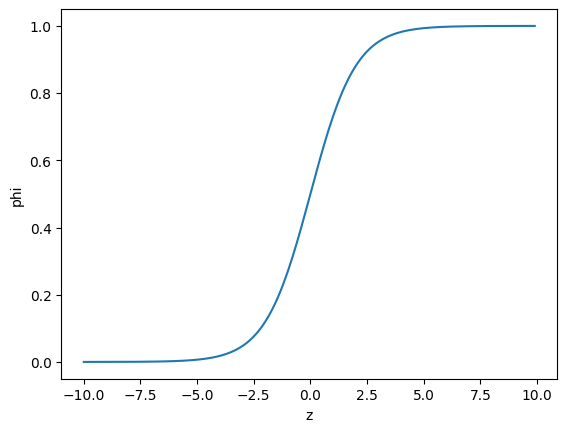

In [ ]:
z =  np.arange(-10, 10, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()


# 로지스틱 회귀를 이용한 이진 분류

In [ ]:
#불리언 인덱싱
char_arr = np.array(['A','B','C','D','E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [ ]:
bs_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
bs_indexes

array([ True, False,  True, False, False, False, False,  True, False,
       False, False,  True, False, False, False,  True,  True, False,
       False,  True, False,  True, False, False, False,  True, False,
       False,  True, False, False, False, False,  True, False, False,
        True,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False,  True, False, False,
        True, False, False, False,  True, False, False, False, False,
       False, False,  True, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False,  True, False,
       False,  True,  True, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False,  True, False,
        True, False, False,  True,  True, False, False, False, False,
       False, False, False, False,  True,  True, False, False,  True,
       False, False])

In [ ]:
train_bs = train_input[bs_indexes]
target_bs = train_target[bs_indexes]

In [ ]:
print(train_bs.shape, target_bs.shape)

(33, 5) (33,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()
lr.fit(train_bs, target_bs)

LogisticRegression()

In [ ]:
lr.predict(train_bs[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [ ]:
target_bs[:5]

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [ ]:
lr.predict_proba(train_bs[:5])

array([[0.99746125, 0.00253875],
       [0.02849095, 0.97150905],
       [0.99461153, 0.00538847],
       [0.98515891, 0.01484109],
       [0.99754417, 0.00245583]])

## 로지스틱 회귀 계수 확인

In [ ]:
print(lr.coef_, lr.intercept_)

[[-0.42060794 -0.60027616 -0.68776093 -1.00279303 -0.74505586]] [-2.19130847]


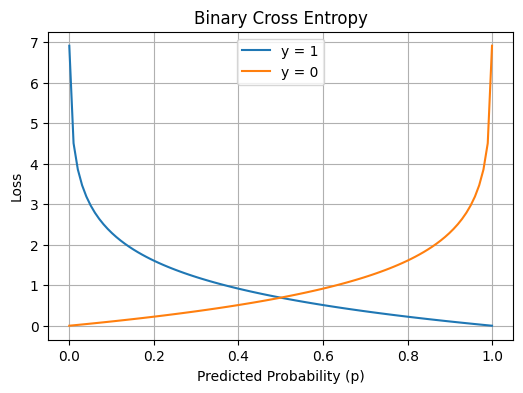

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# p 값 (예측 확률)
p = np.linspace(0.001, 0.999, 100)

# y=1일 때 loss
loss_y1 = -np.log(p)

# y=0일 때 loss
loss_y0 = -np.log(1 - p)

plt.figure(figsize=(6, 4))

plt.plot(p, loss_y1, label="y = 1")
plt.plot(p, loss_y0, label="y = 0")

plt.xlabel("Predicted Probability (p)")
plt.ylabel("Loss")
plt.title("Binary Cross Entropy")
plt.legend()
plt.grid()

plt.show()

## $$-{(y\log(p) + (1 - y)\log(1 - p))} $$


# 로지스틱 회귀로 다중 분류 수행하기


###  이진 분류기를 활용하여 다중 클래스 분류 가능
    * 일대다(OvR 또는 OvA)
    * 일대일(OvO)

### 일대다 방식 활용 예제
    * 숫자 5 예측하기에서 사용했던 이진 분류 방식을 동일하게 모든 숫자에 대해서 실행
    * 각 샘플에 대해 총 10번 각기 다른 이진 분류기를 실행
    * 이후 각 분류기의 결정 점수 중에서 가장 높은 점수를 받은 클래스를 해당 샘플의 클래스로 선택

### 일대일 방식 활용 예제
    * 조합 가능한 모든 클래스 일대일 분류 방식을 진행하여 가장 많은 결투(duell)를 이긴 숫자를 선택
    * MNIST의 경우, 0과 1 구별, 0과 2 구별, ..., 1과 2 구별, 1과 3 구별, ..., 8과 9 구별 등
        (9+8+...+1 = 45)개의 결투를 판별하는 45개의 분류기 활용.
        단, 각 결투에 해당되는 데이터 샘플만 훈련에 사용됨.
    * 각각의 훈련 샘플에 대해 가장 많은 결투를 이긴 숫자의 클래스를 예측값으로 사용함.
        예를 들어, 숫자 1이 9번의 결투를 모두 이기면 숫자 1을 예측값으로 지정함.

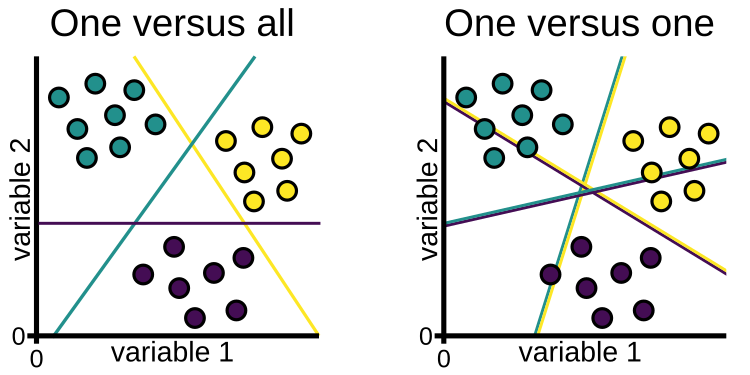

In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_input, train_target)
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9243697478991597
0.925


In [ ]:
lr.predict(test_input[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [ ]:
test_target[:5]

array(['Perch', 'Smelt', 'Pike', 'Whitefish', 'Perch'], dtype=object)

In [ ]:
proba=lr.predict_proba(test_input[:5])
print(np.round(proba, decimals=2))

[[0.   0.01 0.84 0.   0.14 0.01 0.  ]
 [0.   0.   0.05 0.   0.01 0.94 0.  ]
 [0.   0.   0.03 0.93 0.02 0.01 0.  ]
 [0.01 0.03 0.32 0.01 0.56 0.   0.07]
 [0.   0.   0.9  0.   0.09 0.   0.  ]]
